In [13]:

import librosa
import pandas as pd
import numpy as np

SEGMENT_EXTENSION_MS = 3

data = "./features-relative.csv"

df = pd.read_csv(data)

print("Loading and filtering all unique audio files...")
signals = {} 

for file_path in df["file"].unique():
    print(f"Filtering: {file_path}")
    signal, fs = librosa.load(file_path)
    
    signals[file_path] = (signal, fs)


df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    signal_filtered, fs = signals[file_path]
    
    start_sample = row["Start Sample"]
    end_sample = row["End Sample"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment


max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])

Loading and filtering all unique audio files...
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_1.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_2.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_3.wav
Filtering: .\Spontanaktivität\filtered_BP0803902_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI06056410_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605644_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_3.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_4.wav
Filtering: .\Spontanaktivität\filtered_LI0605648_segment_2.wav
Filtering: .\Spontanaktivität\filtered_QD161095_segment_5.wav
Filtering: .\Spontanaktivität\filtered_RN181281_segment_1.wav
Filtering:

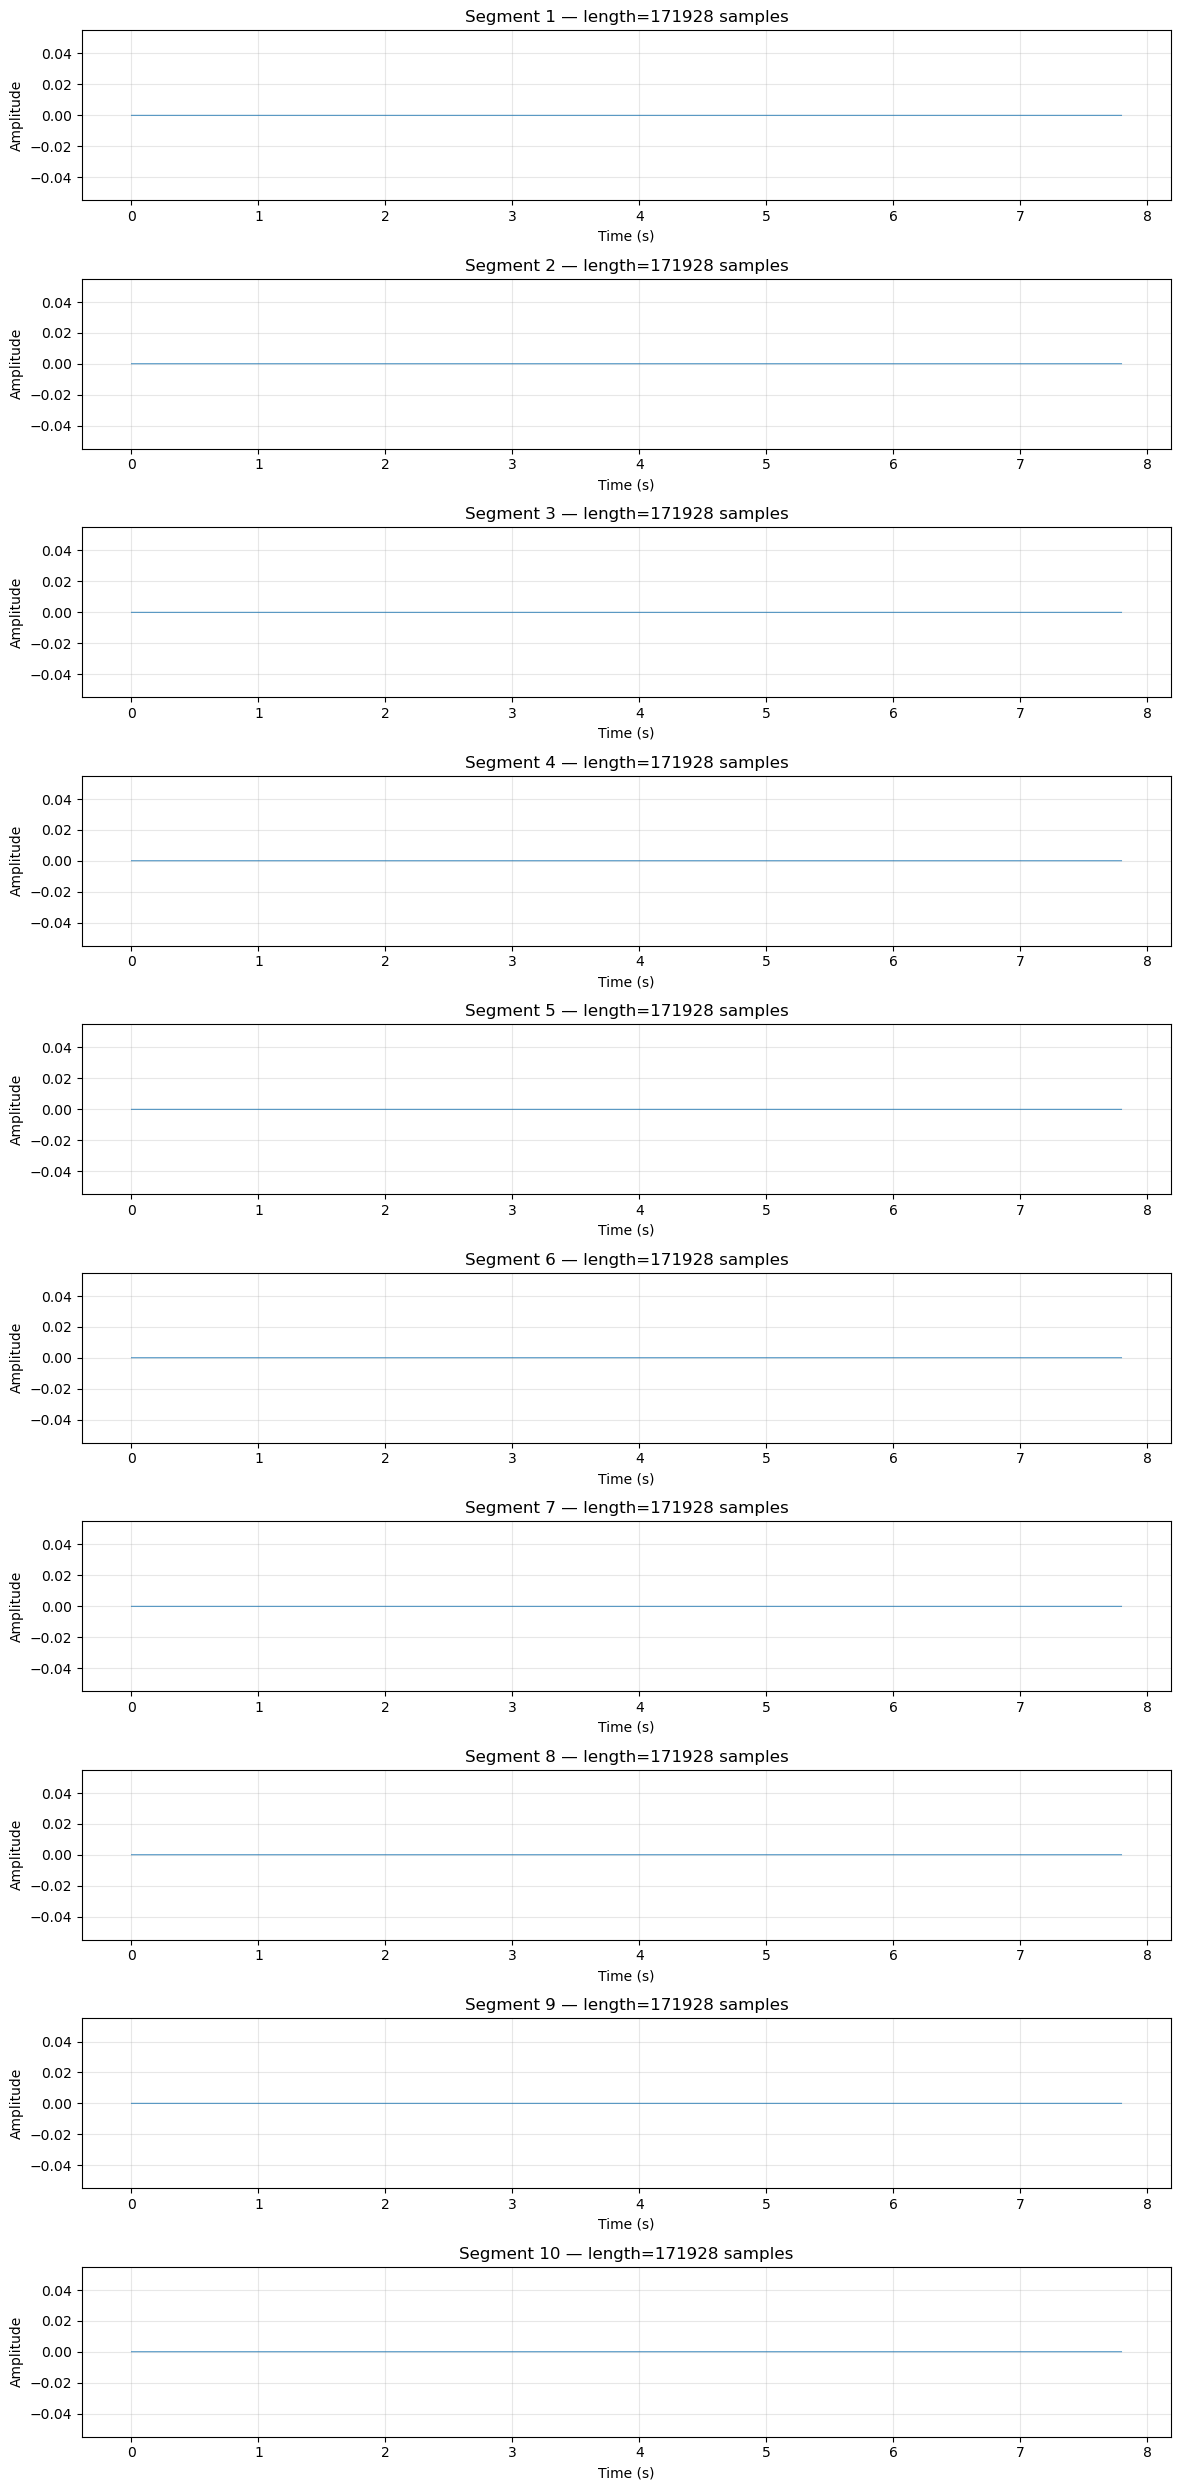

Plotted 10 segments


In [14]:
# Plot first 10 segments (uses `segments` if available, else `df['segment']`)
import matplotlib.pyplot as plt
import numpy as np

# Select source for segments
if 'segments' in globals():
    segs = segments
elif 'df' in globals() and 'segment' in df.columns:
    segs = np.array(df['segment'].tolist())
else:
    raise RuntimeError("No 'segments' variable found and df['segment'] missing")

n_plot = min(10, len(segs))
fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.5 * n_plot))
if n_plot == 1:
    axes = [axes]

for i in range(n_plot):
    seg = segs[i]
    if isinstance(seg, (list, tuple)):
        seg = np.array(seg)
    # If sampling rate available, show time axis
    if 'fs' in globals():
        t = np.arange(len(seg)) / fs
        axes[i].plot(t, seg, linewidth=0.6)
        axes[i].set_xlabel('Time (s)')
    else:
        axes[i].plot(seg, linewidth=0.6)
        axes[i].set_xlabel('Sample')

    axes[i].set_title(f"Segment {i+1} — length={len(seg)} samples")
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plotted {n_plot} segments")